### Basic ChatBot using Langgraph (Graph API)

In [1]:
from typing import Annotated

# Annotated is a Python type hinting mechanism used to define reducer functions that 
# determine how a node's output merges with the existing state.

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

# add_messages is a helper function to add messages to the graph
# it takes a graph and a list of messages and adds them to the graph
# it also adds the START and END states to the graph
# it returns the graph with the messages added



In [2]:
class State(TypedDict):
    # Messages have the type "list". 
    # The `add_messages` function in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model = "groq:llama-3.1-8b-instant")
llm 

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AD64B0BF20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD65B0E3C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Node Functionality

def chatbot(state:State):
    
    return {"messages": [llm.invoke(state["messages"])]}

# This function defines a node in the graph that takes the current state (which includes a list of messages) 
# and returns a new state with an additional message generated by the language model (LLM). 
# The `llm.invoke` method is called with the current messages to generate a response, which is then added to the list of messages in the state.

In [7]:
# Constructing the graph

# Adding nodes to the graph
graph_builder.add_node("llm-Chatbot",chatbot)

# Adding edges to the graph
graph_builder.add_edge(START,"llm-Chatbot")
graph_builder.add_edge("llm-Chatbot",END)

# Compile the graph
graph = graph_builder.compile()

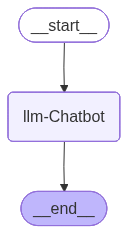

In [8]:
# Visualize the graph

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [9]:
from groq import Groq

client = Groq()
models = client.models.list()

for model in models.data:
    print(model.id)

allam-2-7b
groq/compound-mini
canopylabs/orpheus-v1-english
meta-llama/llama-4-scout-17b-16e-instruct
openai/gpt-oss-safeguard-20b
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-120b
qwen/qwen3-32b
groq/compound
llama-3.3-70b-versatile
llama-3.1-8b-instant
openai/gpt-oss-20b
whisper-large-v3
whisper-large-v3-turbo


In [10]:
response = graph.invoke({"messages": "Hello, how are you?"})

In [11]:
response["messages"][-1].content

"I'm functioning properly, thank you for asking. I'm a large language model, so I don't have feelings in the same way humans do, but I'm here to help answer any questions or provide information you need. How can I assist you today?"

### ChatBot with Tools 

In [6]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': '## Paris facts: Paris, the **capital of France**. Paris is the **capital of France**, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. ## Paris facts: Paris history. From the Romans to the Vth Republic, Paris has a rich 2000 year history. See details of Paris history. ## Paris facts: Paris, a world city. Paris is a world capital city of shopping and fashion, with Channel, Dior, Vuitton, Yves Saint Laurent among many other top french fashion brands. ## Paris facts: the capital of France in history. Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital o

In [31]:
# Custom Function tools (How does llm read the docs string and use it to invoke the tool?)

def multiply(x: int, y: int) -> int:
    """
    Multiply x and y

    Args:
        x (int): first int
        y (int): second int

    Returns:
        int: output int.
    
    """
    return x * y

In [32]:
tools = [tool, multiply]

In [33]:
llm_with_tool = llm.bind_tools(tools)

In [34]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AD64B0BF20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD65B0E3C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

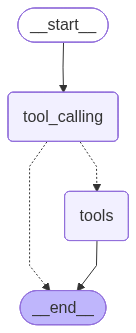

In [49]:
# StateGraph

from langgraph.graph import StateGraph,START,END

from langgraph.prebuilt import ToolNode,tools_condition


# Node Definition

def tool_calling(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph Construction

builder = StateGraph(State)

builder.add_node("tool_calling", tool_calling)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling")
builder.add_conditional_edges(
    "tool_calling",
    
    # If the latest message from the assaistant contains a tool call, the tools condition route to the tool node
    # If not, it routes to the END state

    tools_condition
)

builder.add_edge("tools", END)

graph_with_tools = builder.compile()

from IPython.display import Image, display
display(Image(graph_with_tools.get_graph().draw_mermaid_png()))



In [50]:
response = graph_with_tools.invoke({"messages": "What is the recent ai news in 5 points?"})

In [51]:
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let\'s Data Science", "score": 0.81757444, "published_date": "Sat, 23 May 2026 09:06:58 GMT", "content": "## Scoring Rationale\\n\\nThe story is a notable signal about industry attention to advanced safety concerns and hiring; it affects practitioners via talent markets and research priorities but does not by itself change technical capabilities.\\n\\nMoreOpenAI news→\\n\\nPractice interview problems based on real data\\n\\n1,500+ SQL & Python problems across 15 industry datasets — the exact type of data you work with.\\n\\nTry 250 free problems\\n\\n## More AI & Data Science News\\n\\n6.2\\n\\nMay 23\\n\\n### Meta Launch Crashes Reddit Stock Suddenly6.9\\n\\nMay 23\\n\\n### Startups Adopt Claude Code as Default Coding Tool6.2\

In [52]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news in 5 points?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yk1m1ptzm)
 Call ID: yk1m1ptzm
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let's Data Science", "score": 0.81757444, "published_date": "Sat, 23 May 2026 09:06:58 GMT", "content": "## Scoring Rationale\n\nThe story is a notable signal about industry attention to advanced safety concerns and hiring; it affects practitioners via talent markets and rese

In [53]:
response = graph_with_tools.invoke({"messages": "What is 5 multiplied by 4?"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 4?
================================== Ai Message ==================================
Tool Calls:
  multiply (dkd5t8at7)
 Call ID: dkd5t8at7
  Args:
    x: 5
    y: 4
================================= Tool Message =================================
Name: multiply

20


In [54]:
response=graph_with_tools.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5f2w3zrb6)
 Call ID: 5f2w3zrb6
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (fj9w6kqqc)
 Call ID: fj9w6kqqc
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/19/ai-tech-brief-ai-influence-machine/", "title": "AI & Tech Brief: The AI Influence Machine - The Washington Post", "score": 0.80069196, "published_date": "Tue, 19 May 2026 18:56:21 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: The AI Influence Machine. Plus, Scale AI launc

### ReAct Agent Architecture

- So Basically, the RAG agent is used for the breakdown of the question.
- As you can see in the above example, I have asked two questions within one question. In the previous versions, it is very difficult for the LLM to read both of the questions. 
- This RAG Agent architecture has been created, but later on in the latest version the LLM has adapted to read both questions within a single question. 

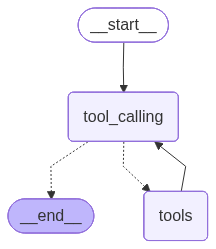

In [55]:
# StateGraph

from langgraph.graph import StateGraph,START,END

from langgraph.prebuilt import ToolNode,tools_condition


# Node Definition

def tool_calling(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph Construction

builder = StateGraph(State)

builder.add_node("tool_calling", tool_calling)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling")
builder.add_conditional_edges(
    "tool_calling",
    
    # If the latest message from the assaistant contains a tool call, the tools condition route to the tool node
    # If not, it routes to the END state

    tools_condition
)

builder.add_edge("tools", "tool_calling")

graph_by_React = builder.compile()

from IPython.display import Image, display
display(Image(graph_by_React.get_graph().draw_mermaid_png()))



In [56]:

response=graph_by_React.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (tyytxyc10)
 Call ID: tyytxyc10
  Args:
    query: recent AI news
    topic: news
  multiply (dwzrv0w8c)
 Call ID: dwzrv0w8c
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/news/ai-backlash-college-commencements-2026/", "title": "Recent commencement speeches show students are souring on AI. How deep is the angst? - CBS News", "score": 0.7018975, "published_date": "Tue, 19 May 2026 21:19:31 GMT", "content": "She previously worked at \"60 Minutes,\" CBSNews.com and CBS News 24/7 as part of the CBS News Associate Program. That dynamic was o

### Adding Memory In Agentic Graph

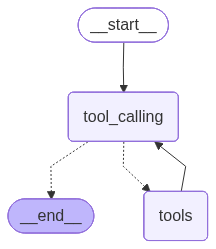

In [59]:
# StateGraph

from langgraph.graph import StateGraph,START,END

from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node Definition

def tool_calling(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph Construction

builder = StateGraph(State)

builder.add_node("tool_calling", tool_calling)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling")
builder.add_conditional_edges(
    "tool_calling",
    
    # If the latest message from the assaistant contains a tool call, the tools condition route to the tool node
    # If not, it routes to the END state

    tools_condition
)

builder.add_edge("tools", "tool_calling")

graph_with_memory = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_with_memory.get_graph().draw_mermaid_png()))



In [61]:
config = {"configurable":{"thread_id":"1"}}

response=graph_with_memory.invoke({"messages":"Hello, my name is rishi"},config=config)

response['messages'][-1].content

"Hello Rishi, it's nice to meet you. Is there anything I can help you with today?"

In [62]:
response = graph_with_memory.invoke({"messages": "What's my name?"}, config=config)

response['messages'][-1].content

'Your name is Rishi.'

### Streaming

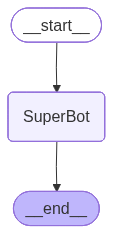

In [65]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [67]:
# INvocation 

config = {"configurable":{"thread_id":"2"}}

graph_builder.invoke({"messages":"Hello, my name is rishi and i like ice cream"},config=config)

{'messages': [HumanMessage(content='Hello, my name is rishi and i like ice cream', additional_kwargs={}, response_metadata={}, id='df431796-34c2-401b-8a15-9bc7d59ad2a8'),
  AIMessage(content="Hello Rishi, nice to meet you. I'm glad to hear you like ice cream. What's your favorite flavor of ice cream? Do you have a go-to spot for ice cream or do you like making it at home?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 47, 'total_tokens': 95, 'completion_time': 0.061827158, 'completion_tokens_details': None, 'prompt_time': 0.003214395, 'prompt_tokens_details': None, 'queue_time': 0.054677295, 'total_time': 0.065041553}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e58a1-32a4-77e3-9671-cbf3ab672d0e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens':

### Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [68]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is rishi And I like volleyball"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Rishi.  It's great to hear that you like volleyball. Volleyball is a fantastic sport that requires skill, strategy, and teamwork. Which position do you prefer to play - setter, hitter, libero, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.094797314, 'completion_tokens_details': None, 'prompt_time': 0.002878771, 'prompt_tokens_details': None, 'queue_time': 0.053250849, 'total_time': 0.097676085}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e58a2-9629-76c2-9682-498c2eb86846-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 49, 'total_tokens': 95})]}}


In [69]:

for chunk in graph_builder.stream({'messages':"Hi,My name is rishi And I like volleyball"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is rishi And I like volleyball', additional_kwargs={}, response_metadata={}, id='2f5bddee-56a1-4344-8f07-bc42ba21f013'), AIMessage(content="Hello Rishi.  It's great to hear that you like volleyball. Volleyball is a fantastic sport that requires skill, strategy, and teamwork. Which position do you prefer to play - setter, hitter, libero, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.094797314, 'completion_tokens_details': None, 'prompt_time': 0.002878771, 'prompt_tokens_details': None, 'queue_time': 0.053250849, 'total_time': 0.097676085}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e58a2-9629-76c2-9682-498c2eb86846-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [70]:
config = {"configurable": {"thread_id": "4"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is rishi and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is rishi and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e58a3-d0ec-7b81-add2-84e28f0e7f0a', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is rishi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='78a4ad9d-1bc7-4202-91d7-4319e5f529a8')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019e58a3-d0f1-7ac2-9233-5f09f64e795e', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:c0fda782-ad25-150f-0b23-016cc43cd55f'}, 'parent_ids': ['019e58a3-d0ec-7b81-add2-84e28f0e7f0a']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':